# Identifing Regulatory DNA Sequences Using Deep Learning Models

## Basic imports

In [ ]:
!pip install pandas numpy matplotlib seaborn optuna scipy scikit-learn tensorflow

In [ ]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from collections import Counter
from scipy import stats
from scipy.stats import shapiro, kruskal, mannwhitneyu

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import StratifiedKFold

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.sequence import pad_sequences

DATA_PATH = './DNA_dataset/DNA_multiclass_balanced.parquet'

LABEL2ID = {"ENHANCER": 0, "PROMOTER": 1, "INTERGENIC": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
LABEL_MAP = ["ENHANCER", "PROMOTER", "INTERGENIC"]


## Data Explorations

In [2]:
df_balanced = pd.read_parquet(DATA_PATH)

print("\nLabel distribution:")
print(df_balanced["label"].value_counts())

print("\nSequence length statistics:")
print(df_balanced["sequence"].str.len().describe())




Label distribution:
label
2    36131
0    36131
1    36131
Name: count, dtype: int64

Sequence length statistics:
count    108393.000000
mean        249.464698
std         110.516371
min           2.000000
25%         194.000000
50%         251.000000
75%         300.000000
max         573.000000
Name: sequence, dtype: float64


In [3]:
lengths = df_balanced["sequence"].str.len()

groups = [lengths[df_balanced["label"] == i].values for i in range(3)]

# Shapiro-Wilk (normality)
for i, g in enumerate(groups):
    stat, p = shapiro(g[:5000])  # subsample for speed
    print(f"Class {i} Shapiro-Wilk: W={stat:.4f}, p={p:.4e}")

# ANOVA
f_stat, f_p = stats.f_oneway(*groups)
print(f"ANOVA: F={f_stat:.2f}, p={f_p:.4e}")

# Kruskal-Wallis
h_stat, kw_p = kruskal(*groups)
print(f"Kruskal-Wallis: H={h_stat:.2f}, p={kw_p:.4e}")

# Pairwise Mann-Whitney with Bonferroni
pairs = [(0,1),(0,2),(1,2)]
for i,j in pairs:
    u, p = mannwhitneyu(groups[i], groups[j])
    print(f"Class {i} vs {j}: U={u:.0f}, p={p:.4e}")

Class 0 Shapiro-Wilk: W=0.9918, p=2.3036e-16
Class 1 Shapiro-Wilk: W=1.0000, p=1.0000e+00
Class 2 Shapiro-Wilk: W=0.9552, p=1.1414e-36
ANOVA: F=1319.61, p=0.0000e+00
Kruskal-Wallis: H=2332.18, p=0.0000e+00
Class 0 vs 1: U=718157822, p=1.6595e-137
Class 0 vs 2: U=769457772, p=0.0000e+00
Class 1 vs 2: U=748796910, p=5.3214e-294


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
def load_and_analyze(parquet_path):
    print("--- Loading Data ---")
    df = pd.read_parquet(parquet_path, engine='fastparquet')
    
    X = df['sequence'].tolist()
    y = df['label'].values
    
    lengths = [len(s) for s in X]
    limit_95 = int(np.percentile(lengths, 95))
    print(f"Average Length: {np.mean(lengths):.2f}")
    print(f"Max Length in data: {max(lengths)}")
    print(f"95th Percentile Length: {limit_95}") #(Recommended for CNN padding)
    
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42, stratify=y
    )
    
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
    )
    
    print(f"Dataset Split:")
    print(f"  Train: {len(X_train)} samples")
    print(f"  Val:   {len(X_val)} samples (Static validation)")
    print(f"  Test:  {len(X_test)} samples (Held-out)")
    
    return X_train, X_val, X_test, y_train, y_val, y_test, limit_95

path = './DNA_dataset/DNA_multiclass_balanced.parquet'
X_train, X_val, X_test, y_train, y_val, y_test, RECOMMENDED_LEN = load_and_analyze(path)

--- Loading Data ---
Average Length: 249.46
Max Length in data: 573
95th Percentile Length: 452
Dataset Split:
  Train: 75918 samples
  Val:   16216 samples (Static validation)
  Test:  16259 samples (Held-out)


H_0: the SVM model can identify the regulatory areas with high accurecy


H_1: there are DL models that will give us better results

## SVM

In [5]:
print("\n--- SVM Optimization with Optuna ---")
optuna.logging.set_verbosity(optuna.logging.WARNING)

np.random.seed(42)
subset_idx = np.random.choice(len(X_train), size=15000, replace=False)
X_train_sub = [X_train[i] for i in subset_idx]
y_train_sub = y_train[subset_idx]

def objective(trial):
    k_mer = trial.suggest_int('k_mer', 3, 6)
    c_param = trial.suggest_float('C', 1e-3, 10, log=True)
    
    vectorizer = CountVectorizer(analyzer='char', ngram_range=(k_mer, k_mer))
    X_vec = vectorizer.fit_transform(X_train_sub)
    
    X_tr, X_val_opt, y_tr, y_val_opt = train_test_split(X_vec, y_train_sub, test_size=0.25, random_state=42)
    
    # LinearSVC (non-linear SVM was way too heavy for tuning on this dataset)
    clf = LinearSVC(C=c_param, dual=False, max_iter=2000)
    clf.fit(X_tr, y_tr)
    
    return clf.score(X_val_opt, y_val_opt)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15)

print(f"Best Params: {study.best_params}")

print("\nTraining Final SVM on FULL dataset...")
best_k = study.best_params['k_mer']
best_c = study.best_params['C']

final_vec = CountVectorizer(analyzer='char', ngram_range=(best_k, best_k))
X_train_svm = final_vec.fit_transform(X_train)
X_test_svm = final_vec.transform(X_test)

svm_model = LinearSVC(C=best_c, dual=False, max_iter=5000, verbose=1)
svm_model.fit(X_train_svm, y_train)

y_pred_svm = svm_model.predict(X_test_svm)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Final Accuracy: {acc_svm:.4f}")



--- SVM Optimization with Optuna ---
Best Params: {'k_mer': 5, 'C': 0.0015850710033202913}

Training Final SVM on FULL dataset...
[LibLinear]iter  1 act 4.395e+01 pre 4.212e+01 delta 2.715e-01 f 1.203e+02 |g| 7.693e+02 CG   4
cg reaches trust region boundary
iter  2 act 6.029e+00 pre 5.552e+00 delta 3.027e-01 f 7.638e+01 |g| 1.069e+02 CG   5
cg reaches trust region boundary
iter  3 act 2.673e+00 pre 2.633e+00 delta 3.075e-01 f 7.035e+01 |g| 4.274e+01 CG   7
cg reaches trust region boundary
iter  4 act 7.740e-01 pre 7.476e-01 delta 3.279e-01 f 6.768e+01 |g| 1.497e+01 CG  14
cg reaches trust region boundary
iter  5 act 2.484e-01 pre 2.497e-01 delta 3.367e-01 f 6.691e+01 |g| 3.980e+00 CG  13
cg reaches trust region boundary
iter  6 act 1.966e-01 pre 1.956e-01 delta 3.450e-01 f 6.666e+01 |g| 4.273e+00 CG  18
iter  7 act 4.799e-02 pre 4.802e-02 delta 3.450e-01 f 6.646e+01 |g| 1.515e+00 CG  30
iter  8 act 3.298e-04 pre 4.031e-04 delta 3.450e-01 f 6.641e+01 |g| 2.066e-01 CG  31
iter  9 act 5

In [6]:
print(f"SVM Final Accuracy: {acc_svm:.4f}")

SVM Final Accuracy: 0.7204


## CNN (1D-CNN on 'Genomic Image')

### Helper Functions

In [7]:
# --- 1. Preprocessing Functions ---
DNA_DICT = {'A': 0, 'C': 1, 'G': 2, 'T': 3, 'N': 4}
COMPLEMENT = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C', 'N': 'N'}

def encode_and_pad(sequences, max_len):
    encoded_list = []
    for seq in sequences:
        num_seq = [DNA_DICT.get(base, 4) for base in seq]
        encoded_list.append(num_seq)
    return pad_sequences(encoded_list, maxlen=max_len, padding='post', truncating='post', value=4)


RC_MAP = tf.constant([3, 2, 1, 0, 4], dtype=tf.int32)
# A(0)->T(3), C(1)->G(2), G(2)->C(1), T(3)->A(0), N(4)->N(4)

def reverse_complement_ohe(seq_ohe, label):
    seq_ohe = tf.cast(seq_ohe, tf.float32)
    
    apply_rc = tf.random.uniform(()) > 0.5
    
    def do_rc():
        # argmax 
        indices = tf.argmax(seq_ohe, axis=-1, output_type=tf.int32)  # (L,)
        # Complement
        comp_indices = tf.gather(RC_MAP, indices)                     # (L,)
        # Reverse
        rev_comp_indices = tf.reverse(comp_indices, axis=[0])         # (L,)
        # OHE
        rev_comp_ohe = tf.one_hot(rev_comp_indices, depth=5)          # (L, 5)
        return tf.cast(rev_comp_ohe, tf.float32)
    
    seq_out = tf.cond(apply_rc, do_rc, lambda: seq_ohe)
    return seq_out, label

def create_augmented_dataset(X, y, batch_size=32, augment=True, shuffle=True):
    X = X.astype(np.float32)
    y = y.astype(np.float32)
    
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=10000, reshuffle_each_iteration=True)
    
    if augment:
        dataset = dataset.map(reverse_complement_ohe, num_parallel_calls=tf.data.AUTOTUNE)
    
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset


print("All functions defined successfully.")


All functions defined successfully.


I0000 00:00:1771781233.332934  227330 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1032 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:03:00.0, compute capability: 8.6


### Build the model

In [2]:
# --- 3. Model Definition ---
def build_dna_cnn_robust(seq_length, num_classes=3):
    model = models.Sequential([
        layers.Input(shape=(seq_length, 5)),
        
        layers.GaussianNoise(0.1),
        
        layers.Conv1D(filters=32, kernel_size=12, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.0001, l2=0.001)),
        layers.BatchNormalization(),
        layers.SpatialDropout1D(0.2),
        layers.MaxPooling1D(pool_size=4),
        
        layers.Conv1D(filters=64, kernel_size=8, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.0001, l2=0.001)),
        layers.BatchNormalization(),
        layers.SpatialDropout1D(0.3),
        layers.MaxPooling1D(pool_size=4),
        
        layers.Conv1D(filters=32, kernel_size=6, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.0001, l2=0.001)),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        
        layers.Dense(64, activation='relu',
                    kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.0001, l2=0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003, clipnorm=1.0),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

| Layer | Filters | Kernel Size | Output Shape | Notes |
|-------|---------|-------------|--------------|-------|
| Input | — | — | (452, 5) | One-hot encoded |
| GaussianNoise | — | — | (452, 5) | σ = 0.1, training only |
| Conv1D (Block 1) | 32 | 12 | (441, 32) | ReLU, L1=1e-4, L2=1e-3 |
| BatchNorm | — | — | (441, 32) | |
| SpatialDropout1D | — | — | (441, 32) | p = 0.2 |
| MaxPooling1D | — | 4 | (110, 32) | |
| Conv1D (Block 2) | 64 | 8 | (103, 64) | ReLU, L1=1e-4, L2=1e-3 |
| BatchNorm | — | — | (103, 64) | |
| SpatialDropout1D | — | — | (103, 64) | p = 0.3 |
| MaxPooling1D | — | 4 | (25, 64) | |
| Conv1D (Block 3) | 32 | 6 | (20, 32) | ReLU, L1=1e-4, L2=1e-3 |
| BatchNorm | — | — | (20, 32) | |
| GlobalAvgPooling1D | — | — | (32,) | Aggregate across positions |
| Dense | 64 | — | (64,) | ReLU, L1+L2 regularization |
| BatchNorm + Dropout | — | — | (64,) | p = 0.5 |
| Dense (output) | 3 | — | (3,) | Softmax |

### Preparing the data for the CNN model

In [9]:
FINAL_LEN = max(RECOMMENDED_LEN, 200)

# Cross Validation
X_cv_raw = X_train + X_val
y_cv_raw = np.concatenate([y_train, y_val])

print("Encoding data...")
X_cv_padded = encode_and_pad(X_cv_raw, FINAL_LEN)
X_test_padded = encode_and_pad(X_test, FINAL_LEN)

# One-Hot
with tf.device('/CPU:0'):
    X_cv_ohe   = tf.one_hot(X_cv_padded,   depth=5).numpy()
    X_test_ohe = tf.one_hot(X_test_padded, depth=5).numpy()
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=3)

# Cross-Validation
n_splits = 5
kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
cv_scores = []

best_val_loss = np.inf
best_model = None


Encoding data...


### Training the CNN model

Num GPUs Available:  1

--- Starting 5-Fold Cross-Validation ---


Fold 1/5 — preparing data...
Fold 1/5 — building model...
Fold 1/5 — starting training...
Epoch 1/30


2026-02-22 17:27:21.953411: I external/local_xla/xla/service/service.cc:163] XLA service 0x7fb4f8016790 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-22 17:27:21.953436: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2026-02-22 17:27:22.029438: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-22 17:27:22.632495: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-02-22 17:27:22.968433: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-22 17:27:22.968510: I e

 55/576 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3846 - auc: 0.5629 - loss: 1.9776

I0000 00:00:1771781248.354868  227412 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


569/576 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5053 - auc: 0.6874 - loss: 1.5374

...

576/576 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.5822 - auc: 0.7658 - loss: 1.2904 - val_accuracy: 0.6971 - val_auc: 0.8584 - val_loss: 0.9819 - learning_rate: 3.0000e-04
Epoch 2/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6999 - auc: 0.8695 - loss: 0.9445 - val_accuracy: 0.7849 - val_auc: 0.9191 - val_loss: 0.7880 - learning_rate: 3.0000e-04
Epoch 3/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7628 - auc: 0.9109 - loss: 0.7881 - val_accuracy: 0.8129 - val_auc: 0.9405 - val_loss: 0.6735 - learning_rate: 3.0000e-04
Epoch 4/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7899 - auc: 0.9265 - loss: 0.7018 - val_accuracy: 0.8187 - val_auc: 0.9486 - val_loss: 0.6089 - learning_rate: 3.0000e-04
Epoch 5/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8136 - auc: 0.9407 - loss: 0.6218 - val_accuracy: 0.8592 - val_auc: 0.9670 - val_loss: 0.5013 - learning_rate: 3.0000e-04
Epoch 6/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.854

2026-02-22 17:32:35.212169: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-22 17:32:35.212261: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-22 17:32:35.909233: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3908', 108 bytes spill stores, 108 bytes spill loads

2026-02-22 17:32:35.921724: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning

576/576 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4853 - auc: 0.6729 - loss: 1.6010

2026-02-22 17:32:40.411939: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_3', 8 bytes spill stores, 8 bytes spill loads

2026-02-22 17:32:41.961367: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-22 17:32:42.448538: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_325', 36 bytes spill stores, 36 bytes spill loads

2026-02-22 17:32:42.463183: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_325', 200

576/576 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.5559 - auc: 0.7467 - loss: 1.3543 - val_accuracy: 0.6037 - val_auc: 0.8198 - val_loss: 1.0595 - learning_rate: 3.0000e-04
Epoch 2/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6773 - auc: 0.8543 - loss: 0.9884 - val_accuracy: 0.7617 - val_auc: 0.9058 - val_loss: 0.8444 - learning_rate: 3.0000e-04
Epoch 3/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7385 - auc: 0.8949 - loss: 0.8427 - val_accuracy: 0.8093 - val_auc: 0.9365 - val_loss: 0.7049 - learning_rate: 3.0000e-04
Epoch 4/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7821 - auc: 0.9210 - loss: 0.7293 - val_accuracy: 0.8260 - val_auc: 0.9490 - val_loss: 0.6178 - learning_rate: 3.0000e-04
Epoch 5/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8012 - auc: 0.9325 - loss: 0.6593 - val_accuracy: 0.8222 - val_auc: 0.9543 - val_loss: 0.5660 - learning_rate: 3.0000e-04
Epoch 6/30
576/576 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.830

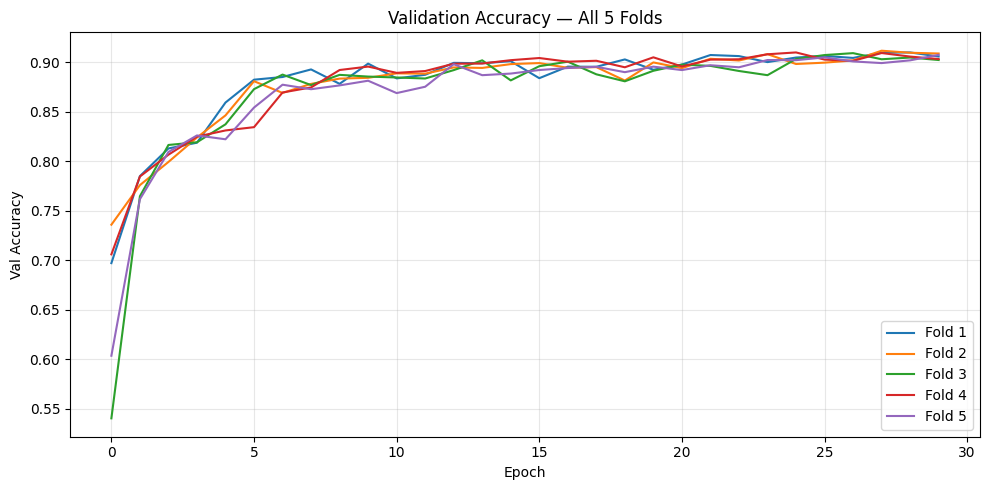

In [10]:
import sys
import gc
import numpy as np
import tensorflow as tf
from tensorflow.keras import callbacks
import matplotlib.pyplot as plt

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
sys.stdout.flush()

BATCH_SIZE = 128
rc_map = np.array([3, 2, 1, 0, 4], dtype=np.int32)  # A<->T, C<->G, N->N

def apply_rc_numpy(X_ohe):
    """Reverse complement augmentation — pure numpy, 50% chance per sample."""
    X_aug = X_ohe.copy()
    mask  = np.random.rand(len(X_aug)) > 0.5
    idxs  = np.argmax(X_aug[mask], axis=-1)          # (n_aug, L)
    comp  = rc_map[idxs]                              # complement
    rev   = comp[:, ::-1]                             # reverse
    X_aug[mask] = np.eye(5, dtype=np.float32)[rev]   # back to OHE
    return X_aug

cv_scores = []
all_fold_histories = []
best_val_loss = float('inf') 

print(f"\n--- Starting {n_splits}-Fold Cross-Validation ---\n")
sys.stdout.flush()

for i, (train_idx, val_idx) in enumerate(kfold.split(X_cv_ohe, y_cv_raw)):
    print(f"\nFold {i+1}/{n_splits} — preparing data...")
    sys.stdout.flush()

    X_f_tr,  X_f_val = X_cv_ohe[train_idx], X_cv_ohe[val_idx]
    y_f_tr,  y_f_val = y_cv_raw[train_idx],  y_cv_raw[val_idx]

    X_f_tr_aug = apply_rc_numpy(X_f_tr)
    y_f_tr_cat  = tf.keras.utils.to_categorical(y_f_tr,  num_classes=3)
    y_f_val_cat = tf.keras.utils.to_categorical(y_f_val, num_classes=3)

    train_ds = tf.data.Dataset.from_tensor_slices(
        (X_f_tr_aug.astype(np.float32), y_f_tr_cat.astype(np.float32))
    ).batch(BATCH_SIZE).prefetch(1)

    val_ds = tf.data.Dataset.from_tensor_slices(
        (X_f_val.astype(np.float32), y_f_val_cat.astype(np.float32))
    ).batch(BATCH_SIZE).prefetch(1)

    print(f"Fold {i+1}/{n_splits} — building model...")
    sys.stdout.flush()

    tf.keras.backend.clear_session()
    model = build_dna_cnn_robust(seq_length=FINAL_LEN, num_classes=3)

    fold_callbacks = [
        callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    ]

    print(f"Fold {i+1}/{n_splits} — starting training...")
    sys.stdout.flush()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        callbacks=fold_callbacks,
        verbose=1
    )

    scores        = model.evaluate(val_ds, verbose=0)
    val_loss_fold = scores[0]
    val_acc_fold  = scores[1]
    cv_scores.append(val_acc_fold)
    all_fold_histories.append(history.history)

    print(f"Fold {i+1} Finished. Val Acc: {val_acc_fold:.4f} | Val Loss: {val_loss_fold:.4f}")
    sys.stdout.flush()

    if val_loss_fold < best_val_loss:
        best_val_loss = val_loss_fold
        model.save_weights('best_cv_model_weights.weights.h5')
        print(f"--> Saved new best weights with Val Loss: {best_val_loss:.4f}")


    del X_f_tr, X_f_val, y_f_tr, y_f_val
    del X_f_tr_aug, y_f_tr_cat, y_f_val_cat
    del train_ds, val_ds, model
    
    gc.collect()

print(f"\nAverage CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

plt.figure(figsize=(10, 5))
for fold_i, hist in enumerate(all_fold_histories):
    val_acc_key = next((k for k in hist.keys() if 'val_' in k and 'acc' in k), None)
    if val_acc_key:
        plt.plot(hist[val_acc_key], label=f'Fold {fold_i+1}', linewidth=1.5)
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy')
plt.title(f'Validation Accuracy — All {n_splits} Folds')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Training Results

--- Final Evaluation using the BEST Model found in CV ---


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Available metrics keys: ['loss', 'compile_metrics']
Available metrics keys: ['loss', 'compile_metrics']

Test Results:
  Loss:      0.2556
  Accuracy:  N/A

Generating predictions...


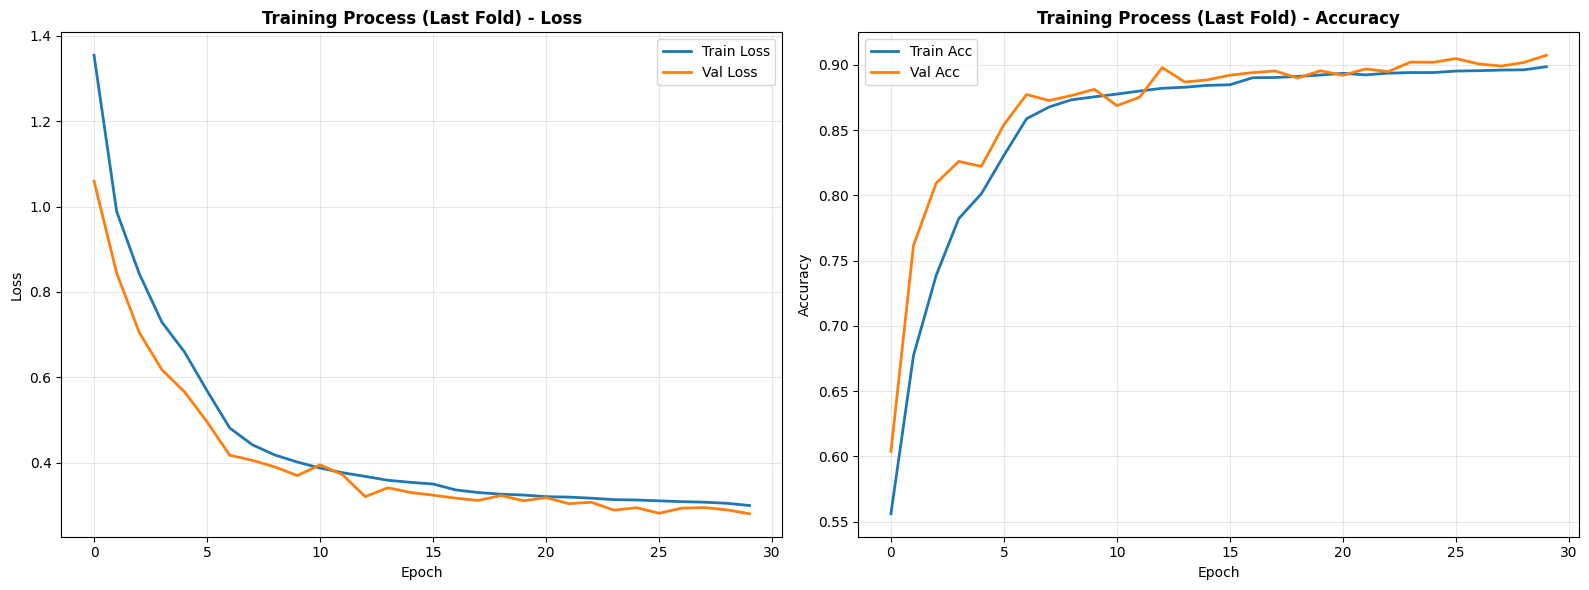


Classification Report:
              precision    recall  f1-score   support

    ENHANCER     0.8712    0.8725    0.8718      5419
    PROMOTER     0.9847    1.0000    0.9923      5420
  INTERGENIC     0.8791    0.8642    0.8716      5420

    accuracy                         0.9122     16259
   macro avg     0.9117    0.9122    0.9119     16259
weighted avg     0.9117    0.9122    0.9119     16259



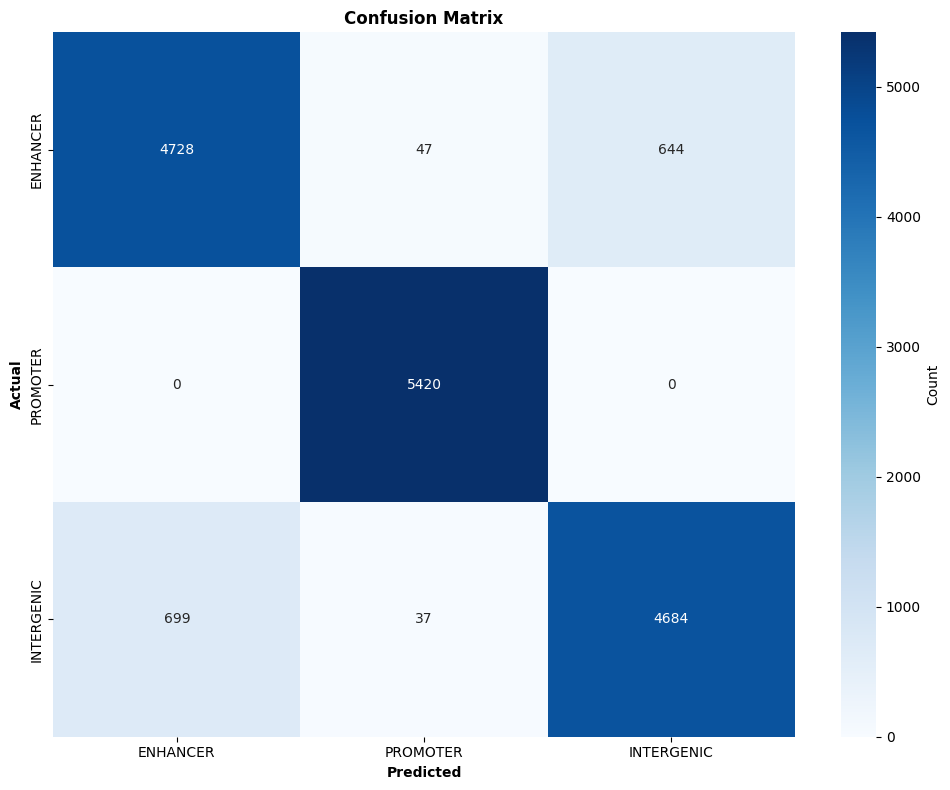

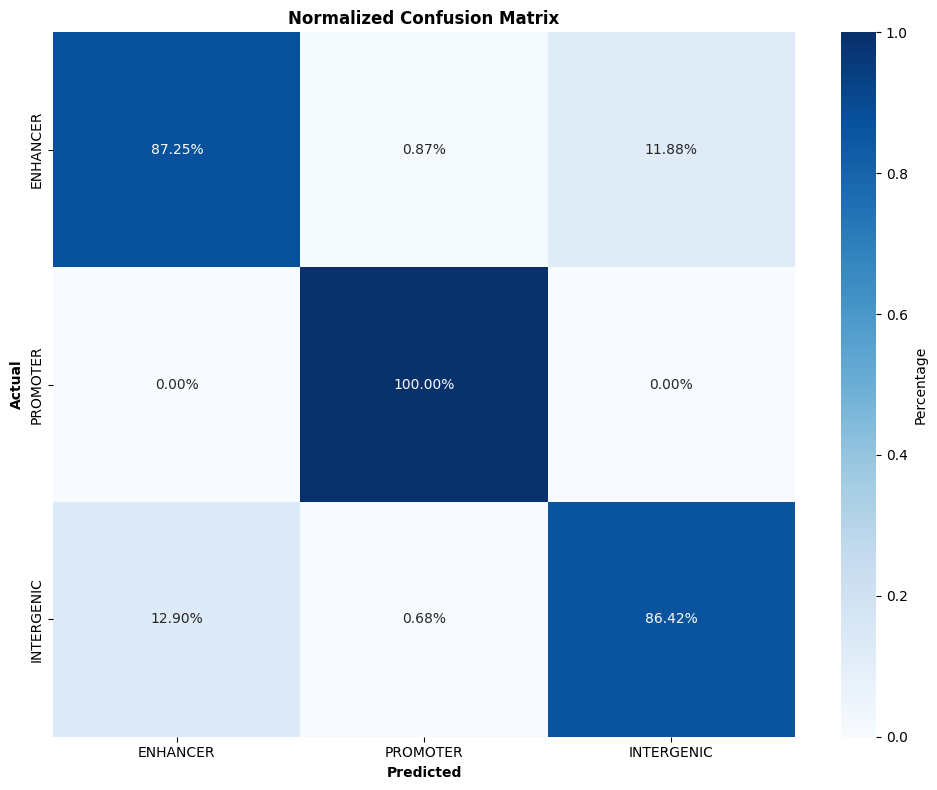


Per-Class Accuracy Analysis:
  ENHANCER: 87.25% (5419 samples)
  PROMOTER: 100.00% (5420 samples)
  INTERGENIC: 86.42% (5420 samples)

Sample Predictions (Random Sample):
  ✓ True: ENHANCER     | Predicted: ENHANCER     | Confidence: 98.13%
  ✗ True: ENHANCER     | Predicted: INTERGENIC   | Confidence: 56.40%
  ✓ True: PROMOTER     | Predicted: PROMOTER     | Confidence: 99.44%
  ✓ True: INTERGENIC   | Predicted: INTERGENIC   | Confidence: 86.56%
  ✓ True: INTERGENIC   | Predicted: INTERGENIC   | Confidence: 81.65%
  ✓ True: PROMOTER     | Predicted: PROMOTER     | Confidence: 99.70%
  ✓ True: INTERGENIC   | Predicted: INTERGENIC   | Confidence: 92.96%
  ✗ True: INTERGENIC   | Predicted: ENHANCER     | Confidence: 80.13%
  ✓ True: INTERGENIC   | Predicted: INTERGENIC   | Confidence: 70.54%
  ✗ True: ENHANCER     | Predicted: INTERGENIC   | Confidence: 67.66%


In [ ]:
print(f"--- Final Evaluation using the BEST Model found in CV ---")

best_model = build_dna_cnn_robust(seq_length=FINAL_LEN, num_classes=3)
best_model.load_weights('best_cv_model_weights.weights.h5')


test_results = best_model.evaluate(X_test_ohe, y_test_cat, verbose=0)
test_metrics = dict(zip(best_model.metrics_names, test_results))

print(f"Available metrics keys: {list(test_metrics.keys())}")

test_results = best_model.evaluate(X_test_ohe, y_test_cat, verbose=0)
test_metrics = dict(zip(best_model.metrics_names, test_results))

print(f"Available metrics keys: {list(test_metrics.keys())}")
print(f"\nTest Results:")
print(f"  Loss:      {test_metrics['loss']:.4f}")

acc_key = next((k for k in test_metrics.keys() if 'acc' in k), None)
if acc_key:
    print(f"  Accuracy:  {test_metrics[acc_key]:.4f}")
else:
    print("  Accuracy:  N/A")

if 'auc' in test_metrics:
    print(f"  AUC:       {test_metrics['auc']:.4f}")

print("\nGenerating predictions...")
predictions     = best_model.predict(X_test_ohe, verbose=0)
predicted_classes = predictions.argmax(axis=1)
y_test_classes  = y_test_cat.argmax(axis=1)

# Plot last fold history
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
last_hist = all_fold_histories[-1]

if 'loss' in last_hist:
    axes[0].plot(last_hist['loss'], label='Train Loss', linewidth=2)
    axes[0].plot(last_hist['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Process (Last Fold) - Loss', fontweight='bold')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    hist_acc_key     = next((k for k in last_hist.keys() if 'acc' in k and 'val' not in k), None)
    hist_val_acc_key = next((k for k in last_hist.keys() if 'val_' in k and 'acc' in k), None)
    if hist_acc_key and hist_val_acc_key:
        axes[1].plot(last_hist[hist_acc_key], label='Train Acc', linewidth=2)
        axes[1].plot(last_hist[hist_val_acc_key], label='Val Acc', linewidth=2)
        axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Training Process (Last Fold) - Accuracy', fontweight='bold')
        axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

class_names = ['ENHANCER', 'PROMOTER', 'INTERGENIC']
print("\nClassification Report:")
print(classification_report(y_test_classes, predicted_classes, target_names=class_names, digits=4))

cm = confusion_matrix(y_test_classes, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontweight='bold'); plt.ylabel('Actual', fontweight='bold')
plt.title('Confusion Matrix', fontweight='bold')
plt.tight_layout(); plt.show()

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Percentage'})
plt.xlabel('Predicted', fontweight='bold'); plt.ylabel('Actual', fontweight='bold')
plt.title('Normalized Confusion Matrix', fontweight='bold')
plt.tight_layout(); plt.show()

print("\nPer-Class Accuracy Analysis:")
for i, class_name in enumerate(class_names):
    class_mask = (y_test_classes == i)
    if class_mask.sum() > 0:
        class_acc = (predicted_classes[class_mask] == i).sum() / class_mask.sum()
        print(f"  {class_name}: {class_acc:.2%} ({class_mask.sum()} samples)")

print("\nSample Predictions (Random Sample):")
random_indices = np.random.choice(len(predicted_classes), 10, replace=False)
for i in random_indices:
    true_class = class_names[y_test_classes[i]]
    pred_class = class_names[predicted_classes[i]]
    confidence = predictions[i][predicted_classes[i]]
    match = "\u2713" if y_test_classes[i] == predicted_classes[i] else "\u2717"
    print(f"  {match} True: {true_class:12s} | Predicted: {pred_class:12s} | Confidence: {confidence:.2%}")


## Final Comperison: SVM vs. CNN


--- Final Comparison: SVM vs. CNN (Held-out Test Set) ---
Training SVM on full training data...
Using best k-mer size from Optuna: 5
[LibLinear]iter  1 act 5.350e+01 pre 5.126e+01 delta 2.743e-01 f 1.460e+02 |g| 9.317e+02 CG   4
cg reaches trust region boundary
iter  2 act 7.463e+00 pre 6.859e+00 delta 3.123e-01 f 9.254e+01 |g| 1.294e+02 CG   5
cg reaches trust region boundary
iter  3 act 3.196e+00 pre 3.167e+00 delta 3.177e-01 f 8.508e+01 |g| 4.625e+01 CG   7
cg reaches trust region boundary
iter  4 act 8.856e-01 pre 8.550e-01 delta 3.374e-01 f 8.188e+01 |g| 1.695e+01 CG  15
cg reaches trust region boundary
iter  5 act 3.317e-01 pre 3.346e-01 delta 3.456e-01 f 8.100e+01 |g| 5.514e+00 CG  14
cg reaches trust region boundary
iter  6 act 2.813e-01 pre 2.771e-01 delta 3.582e-01 f 8.067e+01 |g| 4.979e+00 CG  17
iter  7 act 1.259e-01 pre 1.259e-01 delta 3.582e-01 f 8.039e+01 |g| 2.595e+00 CG  31
iter  8 act 1.533e-03 pre 1.533e-03 delta 3.582e-01 f 8.026e+01 |g| 3.836e-01 CG  36
iter  9 ac

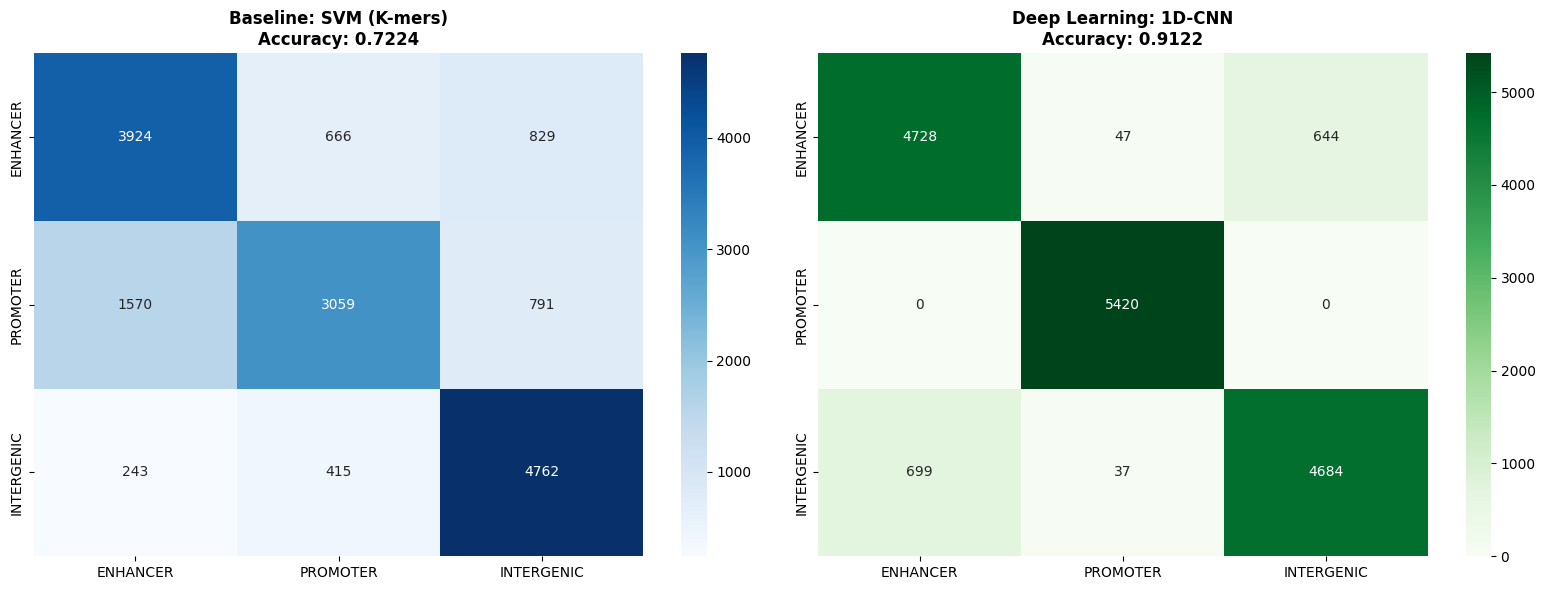


Final Result Summary:
SVM Accuracy: 72.24%
CNN Accuracy: 91.22%
Improvement:  +26.28%

--- Detailed Report (CNN) ---
              precision    recall  f1-score   support

    ENHANCER     0.8712    0.8725    0.8718      5419
    PROMOTER     0.9847    1.0000    0.9923      5420
  INTERGENIC     0.8791    0.8642    0.8716      5420

    accuracy                         0.9122     16259
   macro avg     0.9117    0.9122    0.9119     16259
weighted avg     0.9117    0.9122    0.9119     16259



In [13]:
print("\n--- Final Comparison: SVM vs. CNN (Held-out Test Set) ---")

print("Training SVM on full training data...")
X_train_full_raw = X_train + X_val
y_train_full = np.concatenate([y_train, y_val])

print(f"Using best k-mer size from Optuna: {best_k}")
vectorizer_final = CountVectorizer(analyzer='char', ngram_range=(best_k, best_k))
X_train_vec = vectorizer_final.fit_transform(X_train_full_raw)
X_test_vec  = vectorizer_final.transform(X_test)

svm_model.fit(X_train_vec, y_train_full)

y_pred_svm = svm_model.predict(X_test_vec)
acc_svm    = accuracy_score(y_test, y_pred_svm)

y_pred_cnn_probs = best_model.predict(X_test_ohe, verbose=0)
y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)
acc_cnn    = accuracy_score(y_test, y_pred_cnn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
labels = ['ENHANCER', 'PROMOTER', 'INTERGENIC']

sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title(f'Baseline: SVM (K-mers)\nAccuracy: {acc_svm:.4f}', fontweight='bold')

sns.heatmap(confusion_matrix(y_test, y_pred_cnn), annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title(f'Deep Learning: 1D-CNN\nAccuracy: {acc_cnn:.4f}', fontweight='bold')

plt.tight_layout(); plt.show()

print(f"\nFinal Result Summary:")
print(f"SVM Accuracy: {acc_svm:.2%}")
print(f"CNN Accuracy: {acc_cnn:.2%}")
improvement = (acc_cnn - acc_svm) / acc_svm * 100
print(f"Improvement:  {improvement:+.2f}%")

print("\n--- Detailed Report (CNN) ---")
print(classification_report(y_test, y_pred_cnn, target_names=labels, digits=4))


It is clear that the CNN model is predicting better then the SVM

## CNN Model Interpretability (Saliency Maps)


--- Model Interpretability Analysis ---
Visualizing weights from layer: conv1d_3


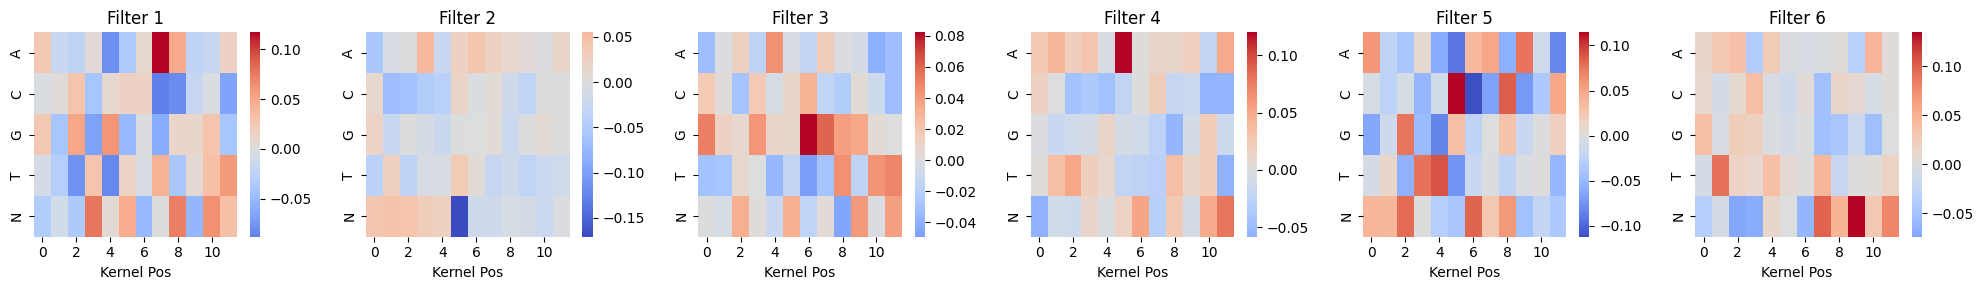

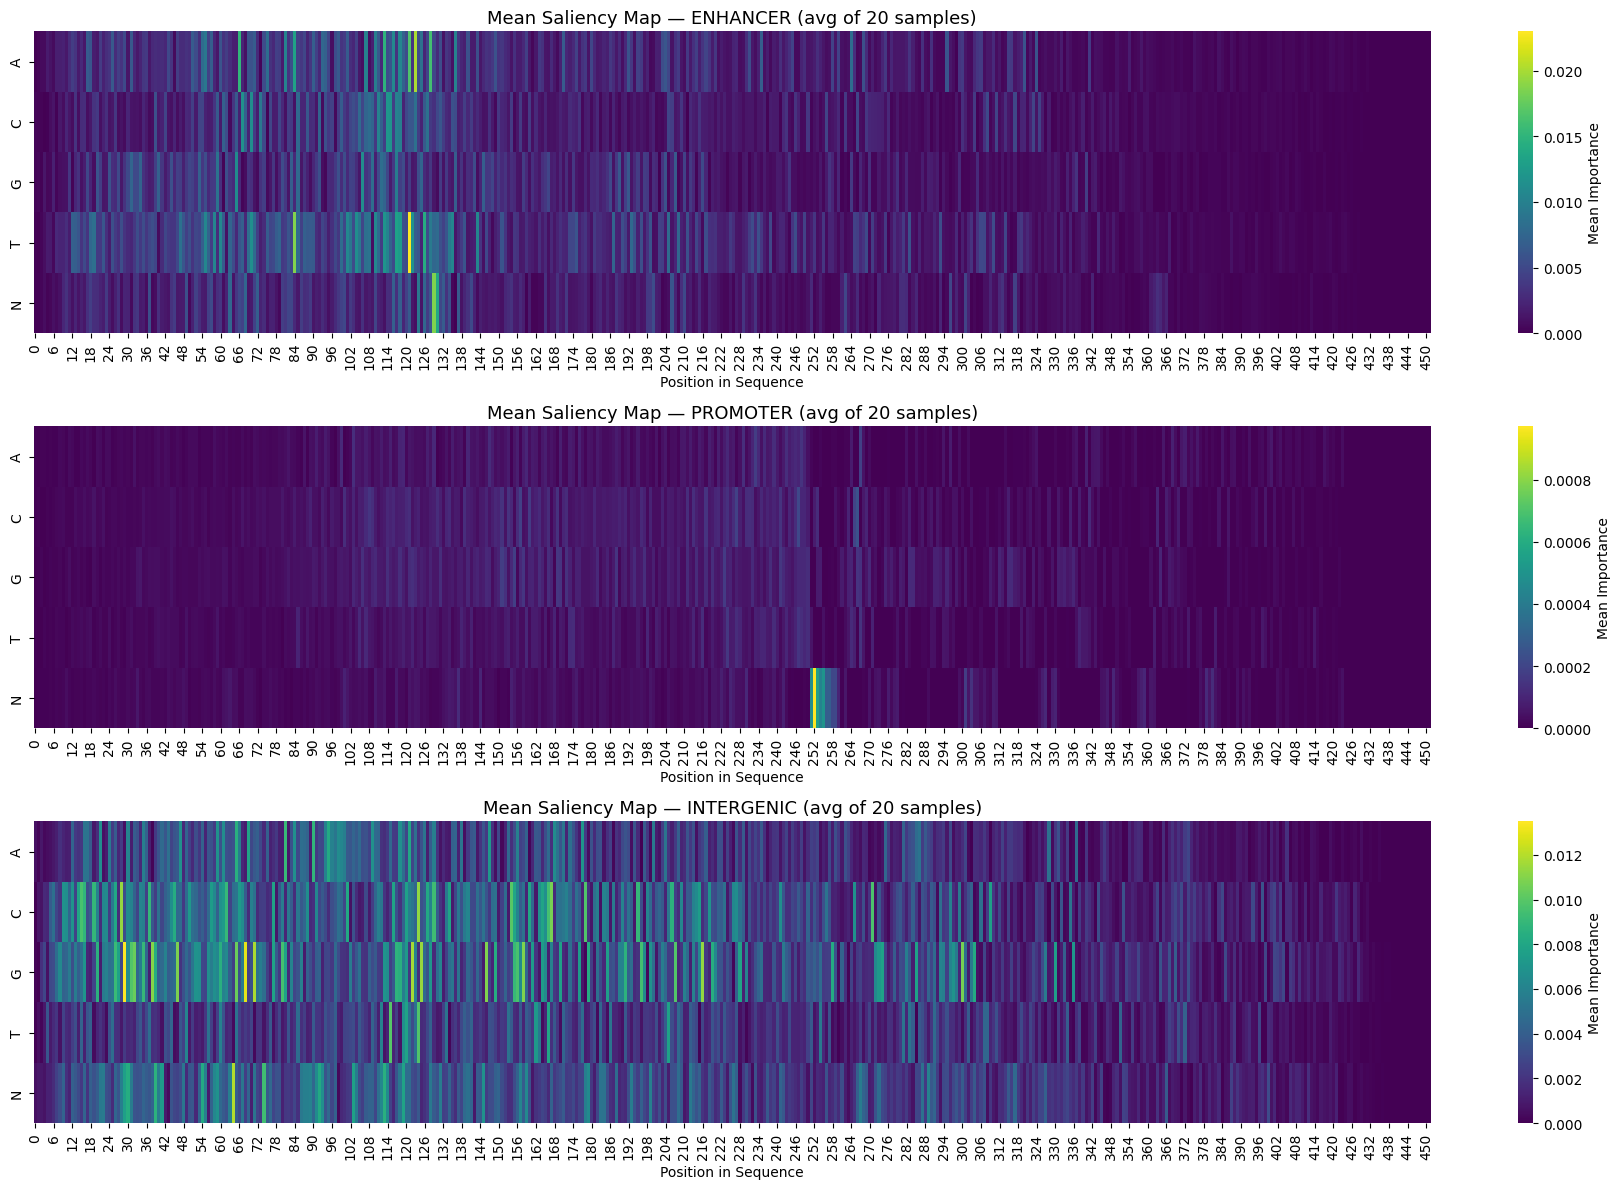

In [ ]:
def compute_saliency(model, seq_ohe, true_label_idx):
    input_tensor = tf.convert_to_tensor([seq_ohe], dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(input_tensor)
        preds = model(input_tensor)
        loss  = preds[0][true_label_idx]
    grads = tape.gradient(loss, input_tensor)[0].numpy()
    return np.maximum(grads, 0)

def plot_mean_saliency(model, X_test_ohe, y_test, id2label_map, n_samples=20):

    class_names = list(id2label_map.values())
    n_classes   = len(class_names)
    
    fig, axes = plt.subplots(n_classes, 1, figsize=(18, 4 * n_classes))
    
    for cls_idx in range(n_classes):
        class_mask    = np.where(y_test == cls_idx)[0]
        selected_idxs = class_mask[:n_samples]  
        saliency_maps = []
        for idx in selected_idxs:
            sal = compute_saliency(model, X_test_ohe[idx], cls_idx)
            saliency_maps.append(sal)
        
        mean_saliency = np.mean(saliency_maps, axis=0)  # (L, 5)
        
        ax = axes[cls_idx] if n_classes > 1 else axes
        sns.heatmap(mean_saliency.T, ax=ax, cmap="viridis",
                    yticklabels=['A','C','G','T','N'],
                    cbar_kws={'label': 'Mean Importance'})
        ax.set_title(f"Mean Saliency Map — {id2label_map[cls_idx]} "
                     f"(avg of {len(selected_idxs)} samples)", fontsize=13)
        ax.set_xlabel("Position in Sequence")
    
    plt.tight_layout()
    plt.show()

def visualize_first_layer_filters(model):
    conv_layers = [layer for layer in model.layers if 'conv1d' in layer.name]
    if not conv_layers:
        print("No Conv1D layers found.")
        return
    first_conv = conv_layers[0]
    weights    = first_conv.get_weights()[0]
    
    n_filters_to_show = min(6, weights.shape[2])
    fig, axes = plt.subplots(1, n_filters_to_show, figsize=(20, 3))
    print(f"Visualizing weights from layer: {first_conv.name}")
    for i in range(n_filters_to_show):
        w = weights[:, :, i]
        sns.heatmap(w.T, ax=axes[i], cmap="coolwarm", center=0,
                    yticklabels=['A','C','G','T','N'])
        axes[i].set_title(f"Filter {i+1}")
        axes[i].set_xlabel("Kernel Pos")
    plt.tight_layout(); plt.show()

print("\n--- Model Interpretability Analysis ---")
visualize_first_layer_filters(best_model)

plot_mean_saliency(best_model, X_test_ohe, y_test, ID2LABEL, n_samples=20)


In [ ]:
best_model.save('dna_cnn_model.keras')